# Sweep Diagnostics: Convergence and Consistency Checks

Two diagnostic axes:
1. **Internal convergence**: Did each model reach close to its optimum? (steps used, seed agreement, convergence rate)
2. **Cross-config consistency**: Are results smooth across config space? (depth monotonicity, neighbor agreement, compression curves)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import math

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('sweep_gpu/sweep_results.csv')

# Derived columns
df['n_over_m'] = df['n'] / df['m']
df['log_n_over_m'] = np.log2(df['n_over_m'])
df['conv_rate'] = df['n_converged'] / df['n_seeds']

# Replicate get_max_steps logic from run_sweep_gpu.py
def get_max_steps(n, m, l):
    if l == 1:
        return 20_000
    base = 40_000
    return min(int(base * math.sqrt(max(1, n / 16))), 200_000)

df['max_steps'] = df.apply(lambda r: get_max_steps(r['n'], r['m'], r['l']), axis=1)
df['steps_frac'] = df['steps_used'] / df['max_steps']

# Split
df_lin = df[df.l == 1]
df_nl = df[df.l >= 2]

print(f"Total configs: {len(df)} ({len(df_lin)} linear, {len(df_nl)} nonlinear)")
print(f"Nonlinear with gain < 0.02: {(df_nl.nonlinear_gain < 0.02).sum()} / {len(df_nl)}")
print(f"Converged (best seed): {df.converged.sum()} / {len(df)}")

Total configs: 216 (54 linear, 162 nonlinear)
Nonlinear with gain < 0.02: 31 / 162
Converged (best seed): 142 / 216


---
## Check 1: Internal Convergence
Did each model actually find its optimum, or did it get stuck?

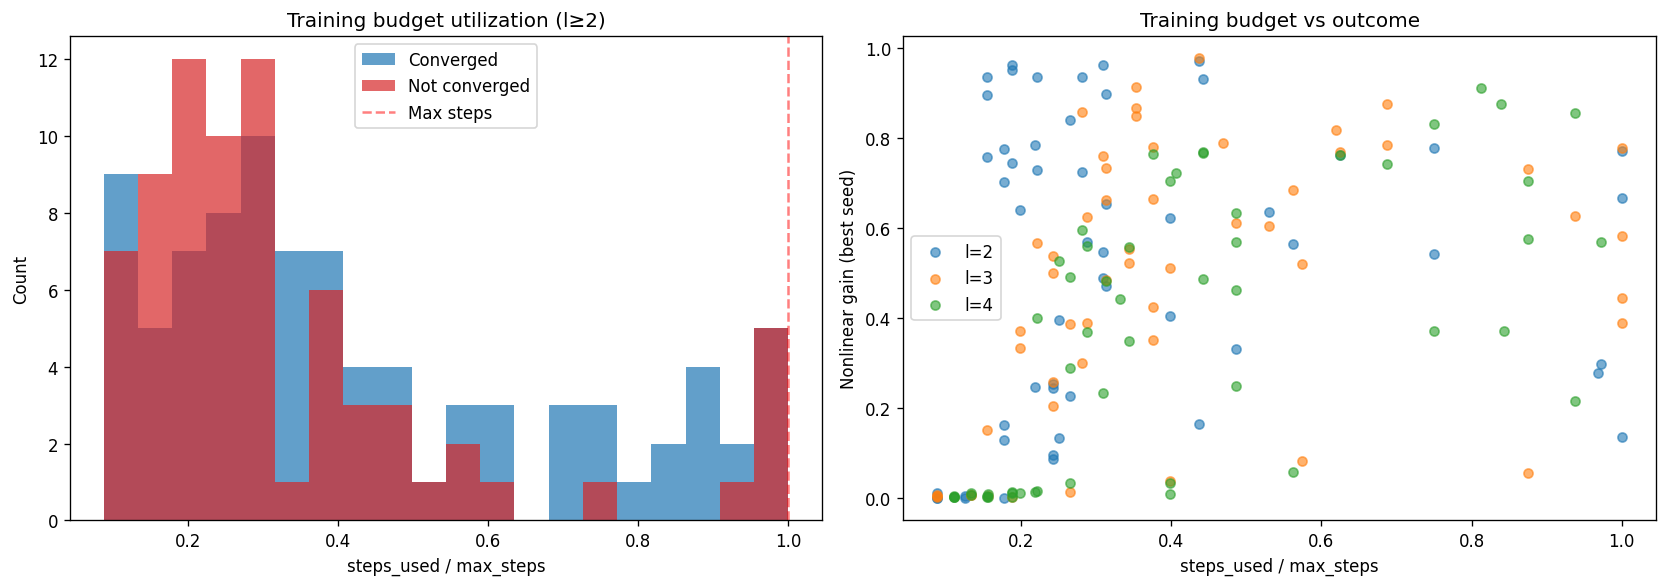

Hit step ceiling (>95%): 10 / 162
Stopped early (<50%): 124 / 162
Early stoppers with gain < 0.02: 31


In [2]:
# 1A: Steps utilization — did models hit the training ceiling?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of steps_frac for nonlinear configs
ax = axes[0]
conv_mask = df_nl['converged'].astype(bool)
ax.hist(df_nl.loc[conv_mask, 'steps_frac'], bins=20, alpha=0.7, label='Converged', color='C0')
ax.hist(df_nl.loc[~conv_mask, 'steps_frac'], bins=20, alpha=0.7, label='Not converged', color='C3')
ax.axvline(1.0, color='red', ls='--', alpha=0.5, label='Max steps')
ax.set_xlabel('steps_used / max_steps')
ax.set_ylabel('Count')
ax.set_title('Training budget utilization (l≥2)')
ax.legend()

# Scatter: steps_frac vs nonlinear_gain
ax = axes[1]
for l_val in [2, 3, 4]:
    mask = df_nl.l == l_val
    ax.scatter(df_nl.loc[mask, 'steps_frac'], df_nl.loc[mask, 'nonlinear_gain'],
              alpha=0.6, label=f'l={l_val}', s=30)
ax.set_xlabel('steps_used / max_steps')
ax.set_ylabel('Nonlinear gain (best seed)')
ax.set_title('Training budget vs outcome')
ax.legend()

plt.tight_layout()
plt.show()

# Summary stats
hit_ceiling = df_nl[df_nl.steps_frac > 0.95]
stopped_early = df_nl[df_nl.steps_frac < 0.5]
print(f"Hit step ceiling (>95%): {len(hit_ceiling)} / {len(df_nl)}")
print(f"Stopped early (<50%): {len(stopped_early)} / {len(df_nl)}")
print(f"Early stoppers with gain < 0.02: {(stopped_early.nonlinear_gain < 0.02).sum()}")

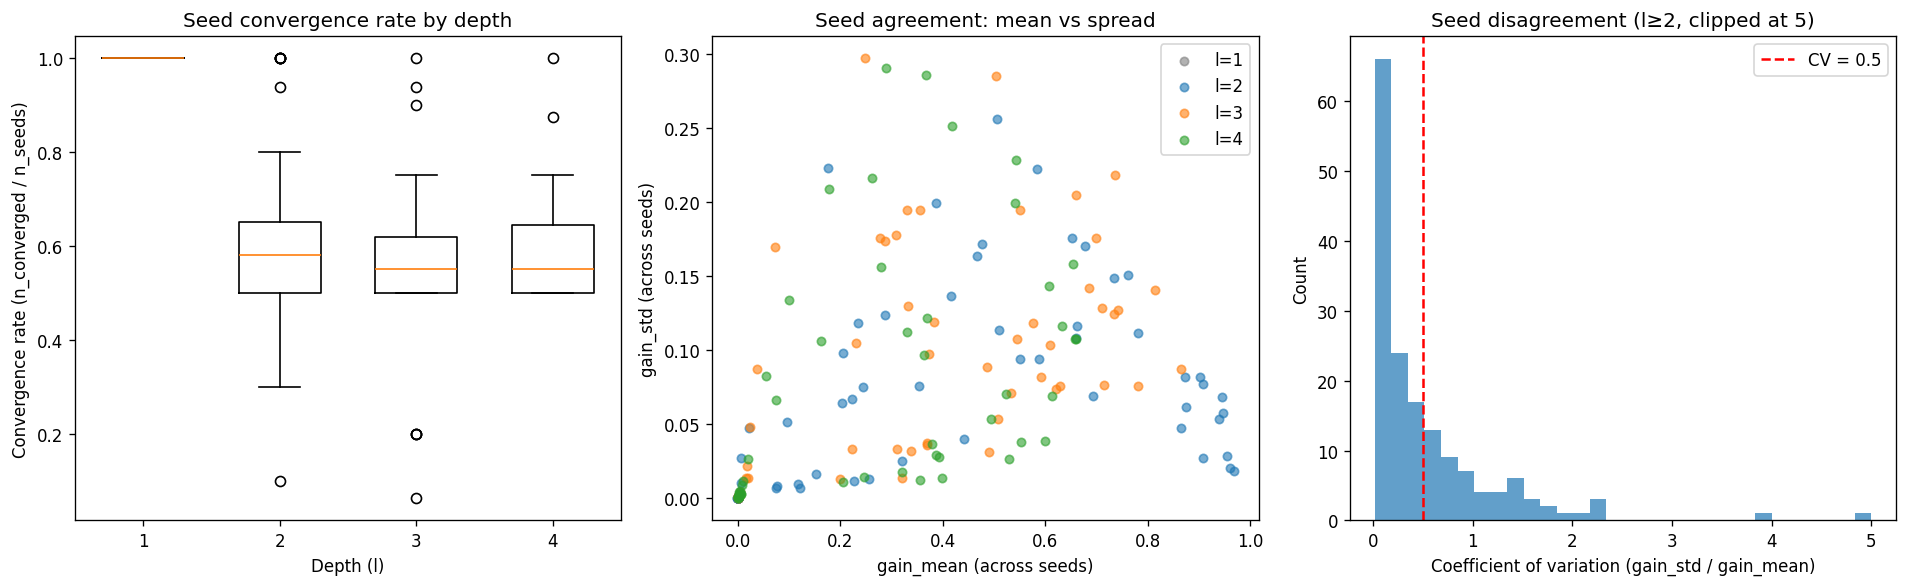

Configs with CV > 0.5: 60 / 162
  n  m  l    S  nonlinear_gain  gain_mean  gain_std  n_converged  n_seeds
 16  2  3 0.95        0.625440   0.330804  0.194733           15       20
 16  2  4 0.95        0.703482   0.262745  0.216184           10       20
 16  4  3 0.95        0.731300   0.286604  0.173611           13       20
 16  4  4 0.95        0.369606   0.098905  0.133850           10       20
 16  8  2 0.90        0.770546   0.387239  0.199265            1       10
 16  8  2 0.95        0.133980   0.095587  0.051705            3       10
 16  8  3 0.85        0.776548   0.503906  0.285379            2       10
 16  8  3 0.90        0.444785   0.309598  0.177682            2       10
 16  8  3 0.95        0.055034   0.018858  0.013660            6       10
 16  8  4 0.85        0.855161   0.417446  0.251677            5       10
 16  8  4 0.90        0.214065   0.075224  0.066674            6       10
 16  8  4 0.95        0.057703   0.018968  0.026413            5       10
 32  2

In [3]:
# 1B: Seed agreement — how reliable is the best-seed result?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Conv rate by depth
ax = axes[0]
for l_val in [1, 2, 3, 4]:
    vals = df[df.l == l_val]['conv_rate']
    ax.boxplot([vals], positions=[l_val], widths=0.6)
ax.set_xlabel('Depth (l)')
ax.set_ylabel('Convergence rate (n_converged / n_seeds)')
ax.set_title('Seed convergence rate by depth')
ax.set_xticks([1, 2, 3, 4])

# gain_std vs gain_mean
ax = axes[1]
colors = {1: 'gray', 2: 'C0', 3: 'C1', 4: 'C2'}
for l_val in [1, 2, 3, 4]:
    mask = df.l == l_val
    ax.scatter(df.loc[mask, 'gain_mean'], df.loc[mask, 'gain_std'],
              alpha=0.6, label=f'l={l_val}', color=colors[l_val], s=25)
ax.set_xlabel('gain_mean (across seeds)')
ax.set_ylabel('gain_std (across seeds)')
ax.set_title('Seed agreement: mean vs spread')
ax.legend()

# Coefficient of variation for nonlinear configs
ax = axes[2]
cv = df_nl['gain_std'] / (df_nl['gain_mean'].abs() + 1e-6)
ax.hist(cv.clip(upper=5), bins=30, color='C0', alpha=0.7)
ax.axvline(0.5, color='red', ls='--', label='CV = 0.5')
ax.set_xlabel('Coefficient of variation (gain_std / gain_mean)')
ax.set_ylabel('Count')
ax.set_title('Seed disagreement (l≥2, clipped at 5)')
ax.legend()

plt.tight_layout()
plt.show()

high_cv = df_nl[cv > 0.5]
print(f"Configs with CV > 0.5: {len(high_cv)} / {len(df_nl)}")
if len(high_cv) > 0:
    print(high_cv[['n', 'm', 'l', 'S', 'nonlinear_gain', 'gain_mean', 'gain_std', 'n_converged', 'n_seeds']].to_string(index=False))

In [4]:
# 1C: "False convergence" detector
# Flag: l>=2, gain < 0.02, but some deeper or same-depth config with same (n, m, S-group) has gain > 0.1
# Also flag if l=2 has gain < 0.02 but l=3 or l=4 for same (n,m,S) has gain > 0.1

suspects = []
for (n, m, S), grp in df.groupby(['n', 'm', 'S']):
    # Best gain at any depth >= 2
    nl_grp = grp[grp.l >= 2]
    if len(nl_grp) == 0:
        continue
    best_nl_gain = nl_grp.nonlinear_gain.max()
    
    for _, row in nl_grp.iterrows():
        flags = []
        # Low gain when siblings have high gain
        if row['nonlinear_gain'] < 0.02 and best_nl_gain > 0.1:
            flags.append('low_gain_vs_siblings')
        # Gain much lower than best sibling (not just near-zero)
        if row['nonlinear_gain'] < best_nl_gain * 0.3 and best_nl_gain > 0.1:
            flags.append('underperforming_vs_siblings')
        # High seed disagreement
        cv = row['gain_std'] / (abs(row['gain_mean']) + 1e-6)
        if cv > 0.5 and row['gain_mean'] > 0.02:
            flags.append('high_seed_variance')
        # Hit step ceiling without converging
        max_s = get_max_steps(n, m, int(row['l']))
        if row['steps_used'] >= max_s * 0.95 and not row['converged']:
            flags.append('hit_ceiling')
        
        if flags:
            suspects.append({
                'n': n, 'm': m, 'l': int(row['l']), 'S': S,
                'gain': row['nonlinear_gain'],
                'gain_mean': row['gain_mean'],
                'gain_std': row['gain_std'],
                'best_sibling_gain': best_nl_gain,
                'conv_rate': row['n_converged'] / row['n_seeds'],
                'steps_frac': row['steps_used'] / max_s,
                'flags': ', '.join(flags),
            })

df_suspects = pd.DataFrame(suspects)
print(f"Suspect configs: {len(df_suspects)} / {len(df_nl)} nonlinear configs")
if len(df_suspects) > 0:
    print()
    # Sort by how far below siblings
    df_suspects['gain_gap'] = df_suspects['best_sibling_gain'] - df_suspects['gain']
    print(df_suspects.sort_values('gain_gap', ascending=False).to_string(index=False))

Suspect configs: 53 / 162 nonlinear configs

  n  m  l    S      gain  gain_mean  gain_std  best_sibling_gain  conv_rate  steps_frac                                             flags  gain_gap
128 16  4 0.90  0.003129   0.002513  0.002170           0.935273     0.7000    0.154689 low_gain_vs_siblings, underperforming_vs_siblings  0.932144
 32  8  4 0.95  0.032755   0.007504  0.009143           0.929927     0.7000    0.265185                       underperforming_vs_siblings  0.897171
128 16  3 0.90  0.038244   0.015037  0.013554           0.935273     0.5000    0.397757                       underperforming_vs_siblings  0.897030
128 16  4 0.95  0.001630   0.000306  0.000545           0.895499     1.0000    0.154689 low_gain_vs_siblings, underperforming_vs_siblings  0.893869
 64 16  4 0.85  0.012488   0.006153  0.002743           0.784795     0.5000    0.218762 low_gain_vs_siblings, underperforming_vs_siblings  0.772307
 64 16  4 0.90  0.012267   0.005094  0.004946           0.784542   

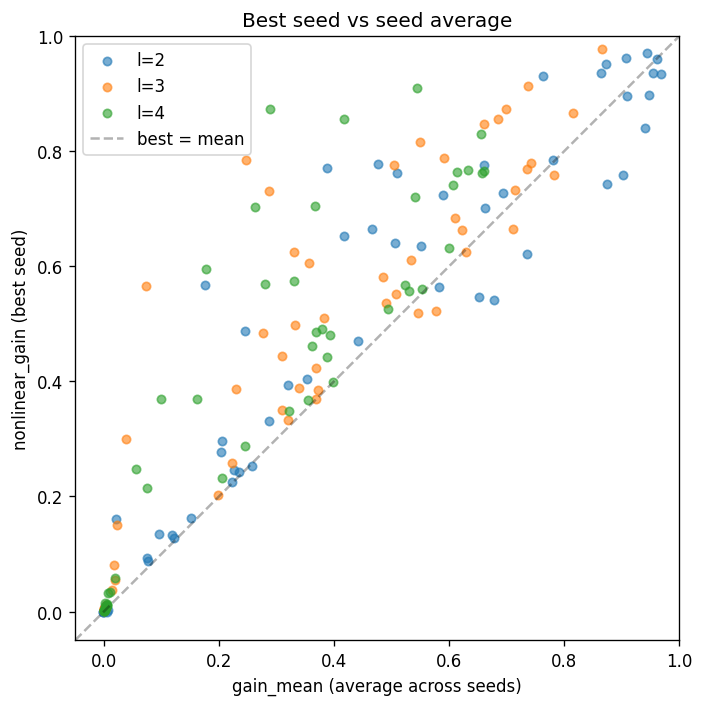

Best seed exceeds mean by: 0.0862 +/- 0.1315
Max excess: 0.5842
Configs where best > mean + 0.1: 53
  n  m  l    S  nonlinear_gain  gain_mean  gain_std  n_seeds
 16  2  2 0.90        0.762438   0.509330  0.113618       20
 16  2  2 0.95        0.777984   0.476033  0.171837       20
 16  2  3 0.95        0.625440   0.330804  0.194733       20
 16  2  4 0.85        0.762284   0.657825  0.107592       20
 16  2  4 0.90        0.740641   0.607167  0.143507       20
 16  2  4 0.95        0.703482   0.262745  0.216184       20
 16  4  3 0.85        0.977041   0.865374  0.087669       20
 16  4  3 0.90        0.874038   0.698945  0.176228       20
 16  4  3 0.95        0.731300   0.286604  0.173611       20
 16  4  4 0.85        0.830259   0.655114  0.158505       20
 16  4  4 0.90        0.909769   0.543651  0.228382       20
 16  4  4 0.95        0.369606   0.098905  0.133850       20
 16  8  2 0.85        0.665209   0.466103  0.163774       10
 16  8  2 0.90        0.770546   0.387239  0.1

In [5]:
# 1D: Best seed vs seed mean — are we relying on lucky seeds?
fig, ax = plt.subplots(figsize=(8, 6))

for l_val in [2, 3, 4]:
    mask = df.l == l_val
    ax.scatter(df.loc[mask, 'gain_mean'], df.loc[mask, 'nonlinear_gain'],
              alpha=0.6, label=f'l={l_val}', s=25)

# Diagonal = best seed matches mean
lims = [-0.05, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.3, label='best = mean')
ax.set_xlabel('gain_mean (average across seeds)')
ax.set_ylabel('nonlinear_gain (best seed)')
ax.set_title('Best seed vs seed average')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Quantify: how much does best exceed mean?
nl_excess = df_nl['nonlinear_gain'] - df_nl['gain_mean']
print(f"Best seed exceeds mean by: {nl_excess.mean():.4f} +/- {nl_excess.std():.4f}")
print(f"Max excess: {nl_excess.max():.4f}")
big_excess = df_nl[nl_excess > 0.1]
print(f"Configs where best > mean + 0.1: {len(big_excess)}")
if len(big_excess) > 0:
    print(big_excess[['n','m','l','S','nonlinear_gain','gain_mean','gain_std','n_seeds']].to_string(index=False))

---
## Check 2: Cross-Config Consistency
Are results smooth and monotonic across config space?

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_65143/2568805028.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


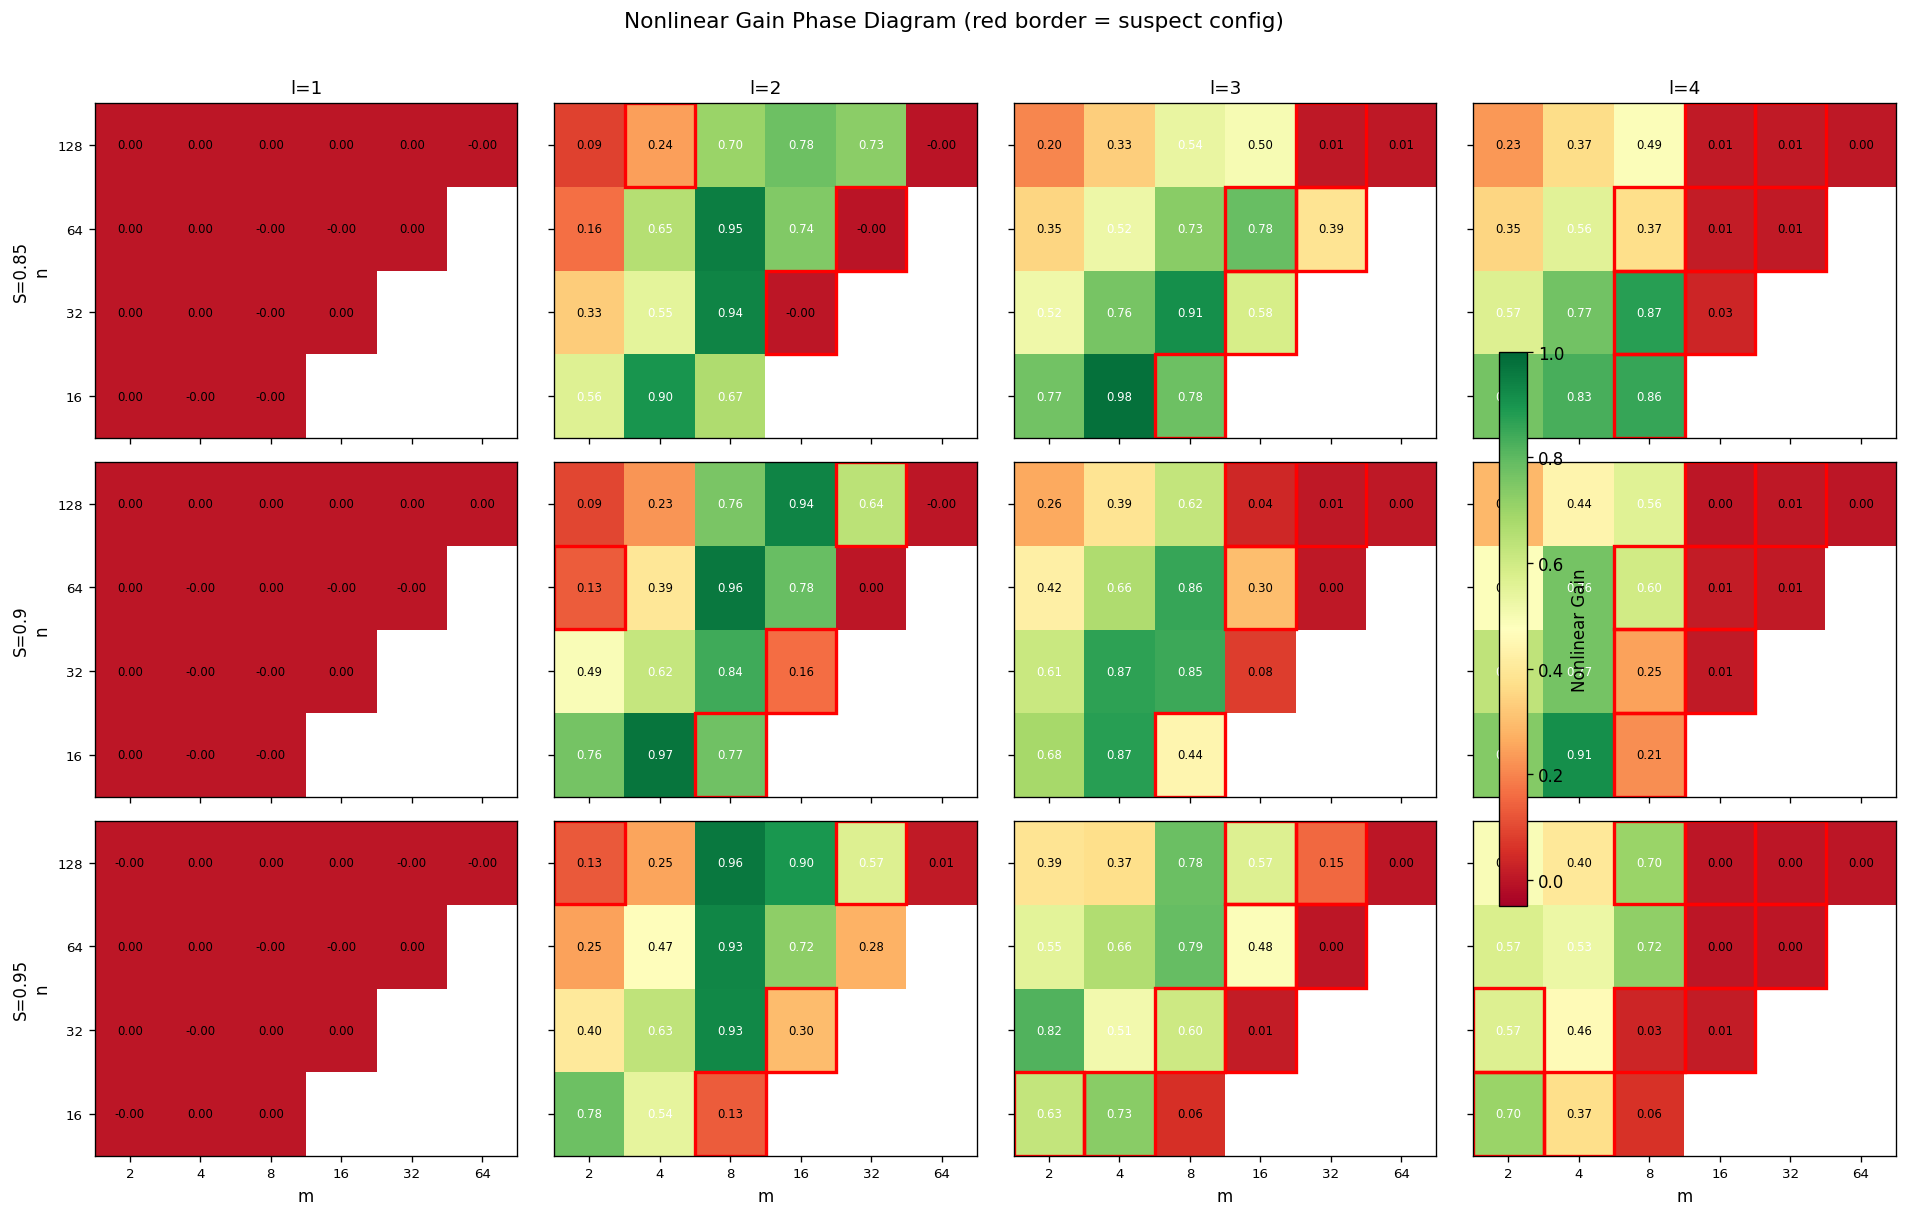

In [6]:
# 2A: Phase diagram heatmaps — nonlinear gain across the full grid
S_vals = sorted(df.S.unique())
l_vals = sorted(df.l.unique())
n_vals = sorted(df.n.unique())
m_vals = sorted(df.m.unique())

fig, axes = plt.subplots(len(S_vals), len(l_vals), figsize=(16, 10),
                          sharex=True, sharey=True)

suspect_set = set()
if len(df_suspects) > 0:
    suspect_set = set(zip(df_suspects.n, df_suspects.m, df_suspects.l, df_suspects.S))

for i, S in enumerate(S_vals):
    for j, l in enumerate(l_vals):
        ax = axes[i, j]
        sub = df[(df.S == S) & (df.l == l)]
        
        # Build grid
        grid = np.full((len(n_vals), len(m_vals)), np.nan)
        for _, row in sub.iterrows():
            ni = n_vals.index(row['n'])
            mi = m_vals.index(row['m'])
            grid[ni, mi] = row['nonlinear_gain']
        
        im = ax.imshow(grid, cmap='RdYlGn', vmin=-0.05, vmax=1.0,
                       aspect='auto', origin='lower')
        
        # Red border on suspect configs
        for _, row in sub.iterrows():
            if (row['n'], row['m'], row['l'], row['S']) in suspect_set:
                ni = n_vals.index(row['n'])
                mi = m_vals.index(row['m'])
                rect = Rectangle((mi-0.5, ni-0.5), 1, 1, 
                                linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
        
        # Annotate values
        for ni, n in enumerate(n_vals):
            for mi, m in enumerate(m_vals):
                if not np.isnan(grid[ni, mi]):
                    color = 'white' if grid[ni, mi] > 0.5 else 'black'
                    ax.text(mi, ni, f'{grid[ni, mi]:.2f}', ha='center', va='center',
                           fontsize=7, color=color)
        
        ax.set_xticks(range(len(m_vals)))
        ax.set_xticklabels(m_vals, fontsize=8)
        ax.set_yticks(range(len(n_vals)))
        ax.set_yticklabels(n_vals, fontsize=8)
        
        if i == 0:
            ax.set_title(f'l={l}', fontsize=11)
        if j == 0:
            ax.set_ylabel(f'S={S}\nn', fontsize=10)
        if i == len(S_vals) - 1:
            ax.set_xlabel('m', fontsize=10)

fig.suptitle('Nonlinear Gain Phase Diagram (red border = suspect config)', fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, label='Nonlinear Gain', shrink=0.6)
plt.tight_layout()
plt.show()

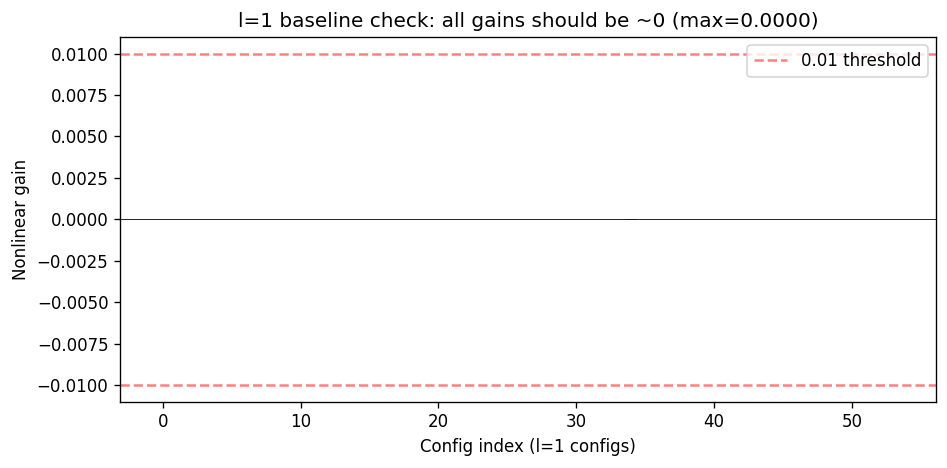

PASS: all l=1 gains in [-0.00002, 0.00002]


In [7]:
# 2B: l=1 sanity check — should all be ~0
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(df_lin)), df_lin['nonlinear_gain'].values, color='gray', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.axhline(0.01, color='red', ls='--', alpha=0.5, label='0.01 threshold')
ax.axhline(-0.01, color='red', ls='--', alpha=0.5)
ax.set_xlabel('Config index (l=1 configs)')
ax.set_ylabel('Nonlinear gain')
ax.set_title(f'l=1 baseline check: all gains should be ~0 (max={df_lin.nonlinear_gain.abs().max():.4f})')
ax.legend()
plt.tight_layout()
plt.show()

if df_lin.nonlinear_gain.abs().max() > 0.01:
    print('WARNING: some l=1 configs have |gain| > 0.01')
    print(df_lin[df_lin.nonlinear_gain.abs() > 0.01][['n','m','l','S','nonlinear_gain']].to_string(index=False))
else:
    print(f'PASS: all l=1 gains in [{df_lin.nonlinear_gain.min():.5f}, {df_lin.nonlinear_gain.max():.5f}]')

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_65143/1513023637.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


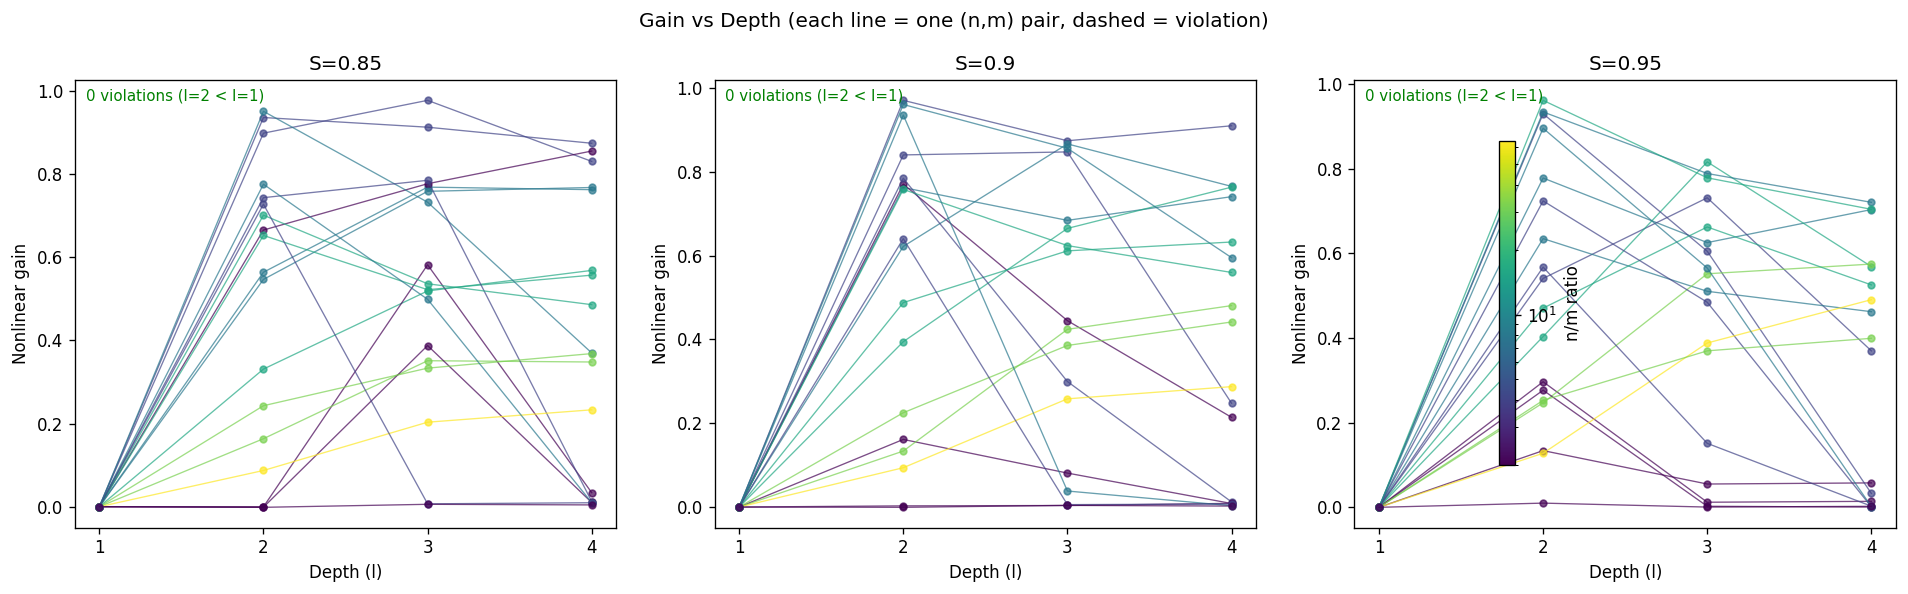

In [8]:
# 2C: Depth monotonicity — gain should increase (or at least not collapse) with depth
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for si, S in enumerate(S_vals):
    ax = axes[si]
    ax.set_title(f'S={S}')
    
    n_over_m_vals = sorted(df[df.S == S]['n_over_m'].unique())
    cmap = plt.cm.viridis
    norm = mcolors.LogNorm(vmin=min(n_over_m_vals), vmax=max(n_over_m_vals))
    
    violations = 0
    for (n, m), grp in df[df.S == S].groupby(['n', 'm']):
        grp = grp.sort_values('l')
        ls = grp['l'].values
        gains = grp['nonlinear_gain'].values
        ratio = n / m
        color = cmap(norm(ratio))
        
        # Check: l=2 should beat l=1
        g1 = grp[grp.l == 1]['nonlinear_gain'].values
        g2 = grp[grp.l == 2]['nonlinear_gain'].values
        is_violation = len(g1) > 0 and len(g2) > 0 and g2[0] < g1[0] - 0.01
        
        lw = 2.5 if is_violation else 0.8
        ls_style = '--' if is_violation else '-'
        ax.plot(ls, gains, marker='o', ms=4, color=color, lw=lw, ls=ls_style, alpha=0.7)
        if is_violation:
            violations += 1
    
    ax.set_xlabel('Depth (l)')
    ax.set_ylabel('Nonlinear gain')
    ax.set_xticks([1, 2, 3, 4])
    ax.text(0.02, 0.98, f'{violations} violations (l=2 < l=1)',
           transform=ax.transAxes, va='top', fontsize=9,
           color='red' if violations > 0 else 'green')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes, label='n/m ratio', shrink=0.7)
fig.suptitle('Gain vs Depth (each line = one (n,m) pair, dashed = violation)', fontsize=12)
plt.tight_layout()
plt.show()

l=4/l=2 ratio: mean=0.99, median=0.81
l=4 < l=2 in 30 / 48 configs with gain_l2 > 0.05


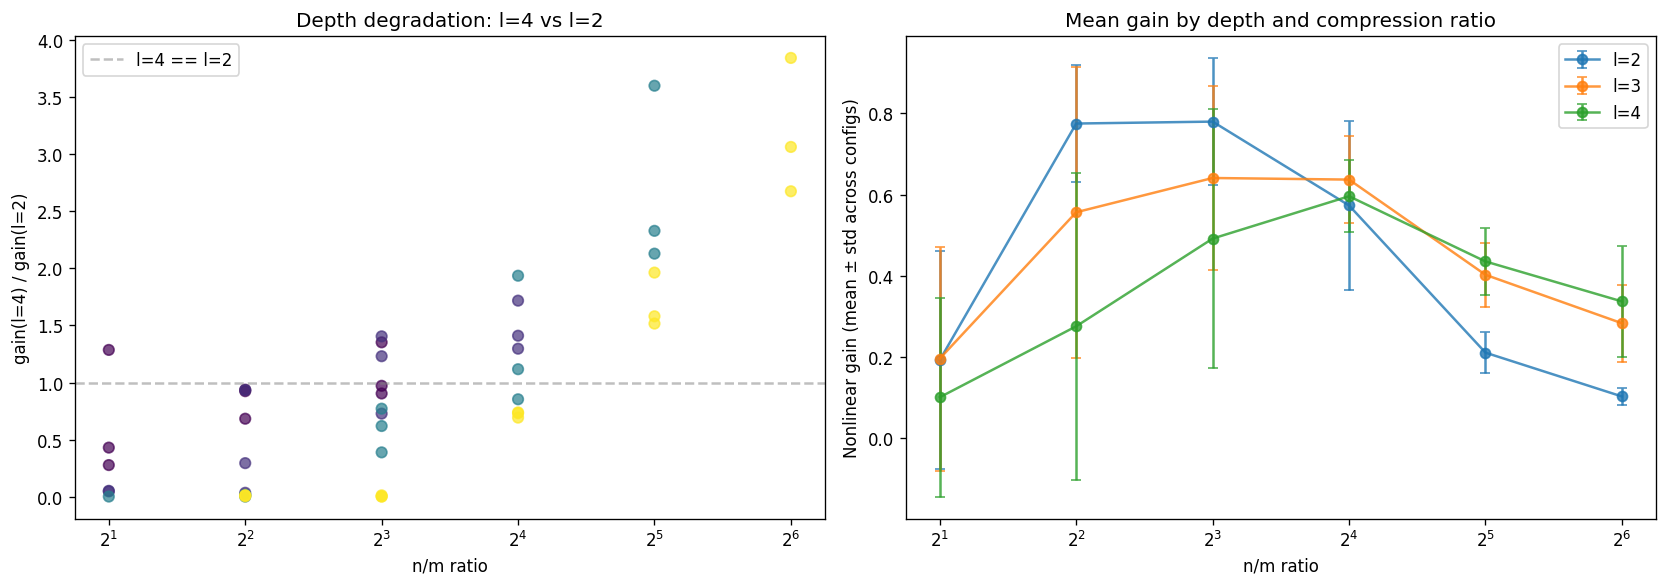

In [9]:
# 2D: Depth profile — is l=4 systematically worse than l=2/l=3?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ratio: gain(l=4) / gain(l=2) for each (n,m,S)
ax = axes[0]
ratios = []
for (n, m, S), grp in df.groupby(['n', 'm', 'S']):
    g2 = grp[grp.l == 2]['nonlinear_gain'].values
    g3 = grp[grp.l == 3]['nonlinear_gain'].values
    g4 = grp[grp.l == 4]['nonlinear_gain'].values
    if len(g2) > 0 and len(g4) > 0 and g2[0] > 0.05:
        ratios.append({'n': n, 'm': m, 'S': S, 'n_over_m': n/m,
                       'gain_l2': g2[0],
                       'gain_l3': g3[0] if len(g3) > 0 else np.nan,
                       'gain_l4': g4[0],
                       'ratio_4_2': g4[0] / g2[0]})

df_ratios = pd.DataFrame(ratios)
if len(df_ratios) > 0:
    ax.scatter(df_ratios['n_over_m'], df_ratios['ratio_4_2'], 
              c=df_ratios['n'], cmap='viridis', s=40, alpha=0.7)
    ax.axhline(1.0, color='gray', ls='--', alpha=0.5, label='l=4 == l=2')
    ax.set_xlabel('n/m ratio')
    ax.set_ylabel('gain(l=4) / gain(l=2)')
    ax.set_title('Depth degradation: l=4 vs l=2')
    ax.set_xscale('log', base=2)
    ax.legend()
    print(f"l=4/l=2 ratio: mean={df_ratios.ratio_4_2.mean():.2f}, median={df_ratios.ratio_4_2.median():.2f}")
    print(f"l=4 < l=2 in {(df_ratios.ratio_4_2 < 1).sum()} / {len(df_ratios)} configs with gain_l2 > 0.05")

# Mean gain by depth
ax = axes[1]
for l_val in [2, 3, 4]:
    sub = df[df.l == l_val]
    means = sub.groupby('n_over_m')['nonlinear_gain'].mean()
    stds = sub.groupby('n_over_m')['nonlinear_gain'].std()
    ax.errorbar(means.index, means.values, yerr=stds.values, 
               marker='o', label=f'l={l_val}', capsize=3, alpha=0.8)

ax.set_xlabel('n/m ratio')
ax.set_ylabel('Nonlinear gain (mean ± std across configs)')
ax.set_title('Mean gain by depth and compression ratio')
ax.set_xscale('log', base=2)
ax.legend()

plt.tight_layout()
plt.show()

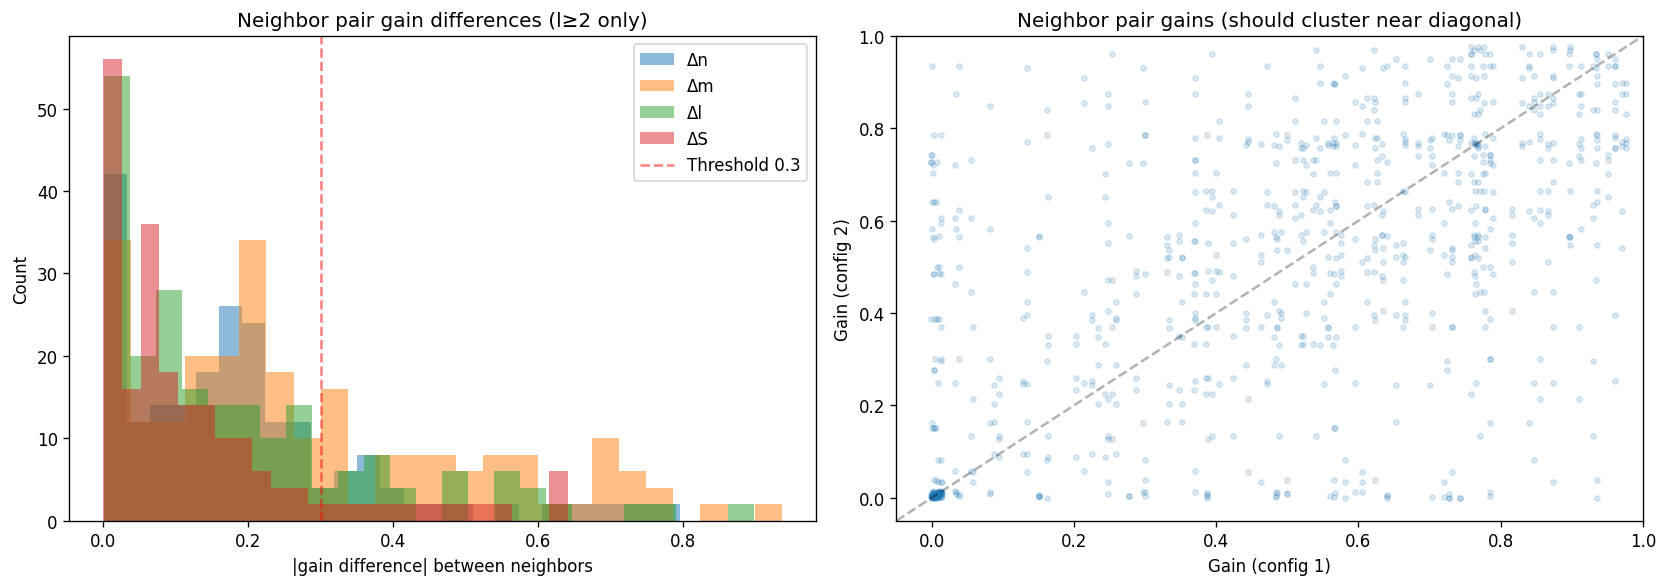

Neighbor pairs with |Δgain| > 0.3: 202 / 900

param     diff        config1        config2     gain1     gain2
    m 0.936041   n32m8l2S0.85  n32m16l2S0.85  0.935768 -0.000273
    m 0.936041  n32m16l2S0.85   n32m8l2S0.85 -0.000273  0.935768
    l 0.897030  n128m16l3S0.9  n128m16l2S0.9  0.038244  0.935273
    l 0.897030  n128m16l2S0.9  n128m16l3S0.9  0.935273  0.038244
    m 0.840110   n32m8l4S0.85  n32m16l4S0.85  0.873887  0.033777
    m 0.840110  n32m16l4S0.85   n32m8l4S0.85  0.033777  0.873887
    n 0.795946   n32m8l2S0.95   n16m8l2S0.95  0.929927  0.133980
    n 0.795946   n16m8l2S0.95   n32m8l2S0.95  0.133980  0.929927
    m 0.781739   n64m32l2S0.9   n64m16l2S0.9  0.002803  0.784542
    m 0.781739   n64m16l2S0.9   n64m32l2S0.9  0.784542  0.002803
    l 0.772307  n64m16l4S0.85  n64m16l3S0.85  0.012488  0.784795
    l 0.772307  n64m16l3S0.85  n64m16l4S0.85  0.784795  0.012488
    m 0.766374    n32m8l3S0.9   n32m16l3S0.9  0.847444  0.081070
    m 0.766374   n32m16l3S0.9    n32m8l3S0.9

In [10]:
# 2E: Neighbor consistency — nearby configs should have similar metrics
# Define neighbors: differ in exactly one param by one grid step

param_steps = {
    'n': sorted(df.n.unique()),
    'm': sorted(df.m.unique()),
    'l': sorted(df.l.unique()),
    'S': sorted(df.S.unique()),
}

neighbor_diffs = []
df_indexed = df.set_index(['n', 'm', 'l', 'S'])

for _, row in df_nl.iterrows():
    n, m, l, S = int(row['n']), int(row['m']), int(row['l']), row['S']
    g = row['nonlinear_gain']
    
    # Check neighbors in each dimension
    for param, steps in param_steps.items():
        if param == 'l' and l == 1:
            continue  # don't compare l=2 to l=1
        val = row[param]
        idx = steps.index(val)
        for di in [-1, 1]:
            ni = idx + di
            if ni < 0 or ni >= len(steps):
                continue
            new_val = steps[ni]
            key = list(row[['n','m','l','S']].values)
            key_dict = {'n': n, 'm': m, 'l': l, 'S': S}
            key_dict[param] = new_val
            # Skip l=1 neighbors and invalid m>=n configs
            if key_dict['l'] == 1:
                continue
            if key_dict['m'] >= key_dict['n']:
                continue
            try:
                nb = df_indexed.loc[(key_dict['n'], key_dict['m'], key_dict['l'], key_dict['S'])]
                nb_g = nb['nonlinear_gain']
                neighbor_diffs.append({
                    'param': param, 'diff': abs(g - nb_g),
                    'config1': f"n{n}m{m}l{l}S{S}",
                    'config2': f"n{key_dict['n']}m{key_dict['m']}l{key_dict['l']}S{key_dict['S']}",
                    'gain1': g, 'gain2': nb_g,
                })
            except KeyError:
                pass

df_nbr = pd.DataFrame(neighbor_diffs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of neighbor diffs
ax = axes[0]
for param in ['n', 'm', 'l', 'S']:
    sub = df_nbr[df_nbr.param == param]
    if len(sub) > 0:
        ax.hist(sub['diff'], bins=25, alpha=0.5, label=f'Δ{param}')
ax.axvline(0.3, color='red', ls='--', alpha=0.5, label='Threshold 0.3')
ax.set_xlabel('|gain difference| between neighbors')
ax.set_ylabel('Count')
ax.set_title('Neighbor pair gain differences (l≥2 only)')
ax.legend()

# Scatter: gain1 vs gain2 for all neighbor pairs
ax = axes[1]
ax.scatter(df_nbr['gain1'], df_nbr['gain2'], alpha=0.15, s=10, color='C0')
lims = [-0.05, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('Gain (config 1)')
ax.set_ylabel('Gain (config 2)')
ax.set_title('Neighbor pair gains (should cluster near diagonal)')
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

# Flag large discrepancies
big_diffs = df_nbr[df_nbr['diff'] > 0.3].drop_duplicates(subset=['config1', 'config2'])
print(f"Neighbor pairs with |Δgain| > 0.3: {len(big_diffs)} / {len(df_nbr)}")
if len(big_diffs) > 0:
    print()
    print(big_diffs.sort_values('diff', ascending=False).head(20).to_string(index=False))

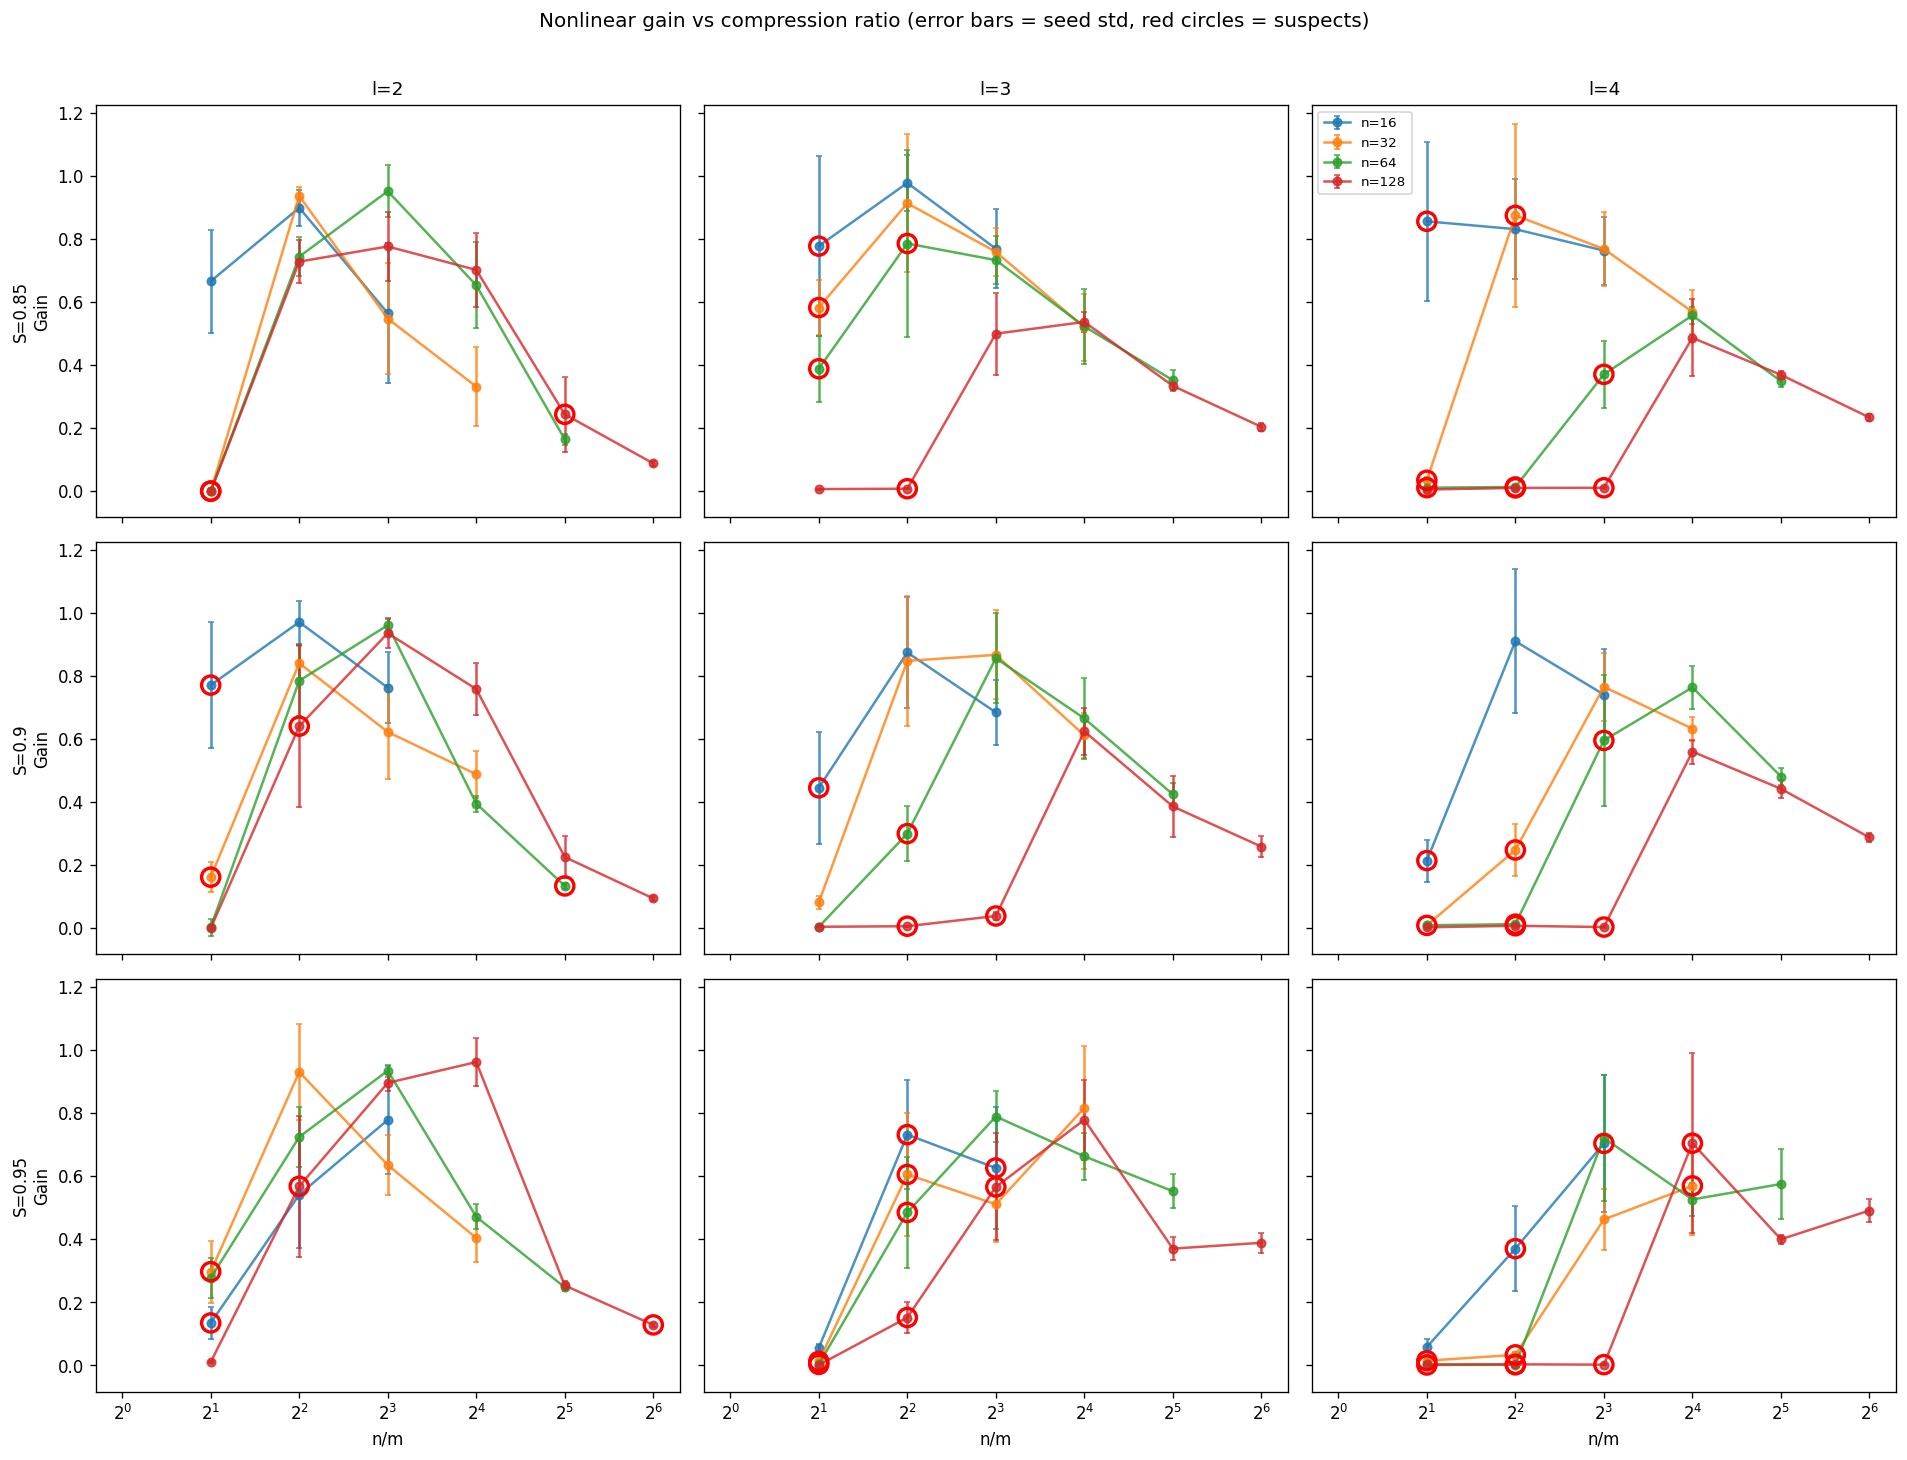

In [11]:
# 2F: Compression ratio curves — gain vs n/m, faceted by (l, S)
fig, axes = plt.subplots(len(S_vals), 3, figsize=(16, 12), sharex=True, sharey=True)

for si, S in enumerate(S_vals):
    for li, l in enumerate([2, 3, 4]):
        ax = axes[si, li]
        sub = df[(df.S == S) & (df.l == l)]
        
        # Color by n
        for n in n_vals:
            s = sub[sub.n == n].sort_values('n_over_m')
            if len(s) == 0:
                continue
            ax.errorbar(s['n_over_m'], s['nonlinear_gain'], 
                       yerr=s['gain_std'], marker='o', ms=5,
                       label=f'n={n}', capsize=2, alpha=0.8)
        
        # Highlight suspects
        for _, row in sub.iterrows():
            if (row['n'], row['m'], row['l'], row['S']) in suspect_set:
                ax.scatter(row['n_over_m'], row['nonlinear_gain'],
                          s=120, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
        
        ax.set_xscale('log', base=2)
        if si == 0:
            ax.set_title(f'l={l}', fontsize=11)
        if li == 0:
            ax.set_ylabel(f'S={S}\nGain', fontsize=10)
        if si == len(S_vals) - 1:
            ax.set_xlabel('n/m', fontsize=10)
        if si == 0 and li == 2:
            ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Nonlinear gain vs compression ratio (error bars = seed std, red circles = suspects)', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_65143/3305600585.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


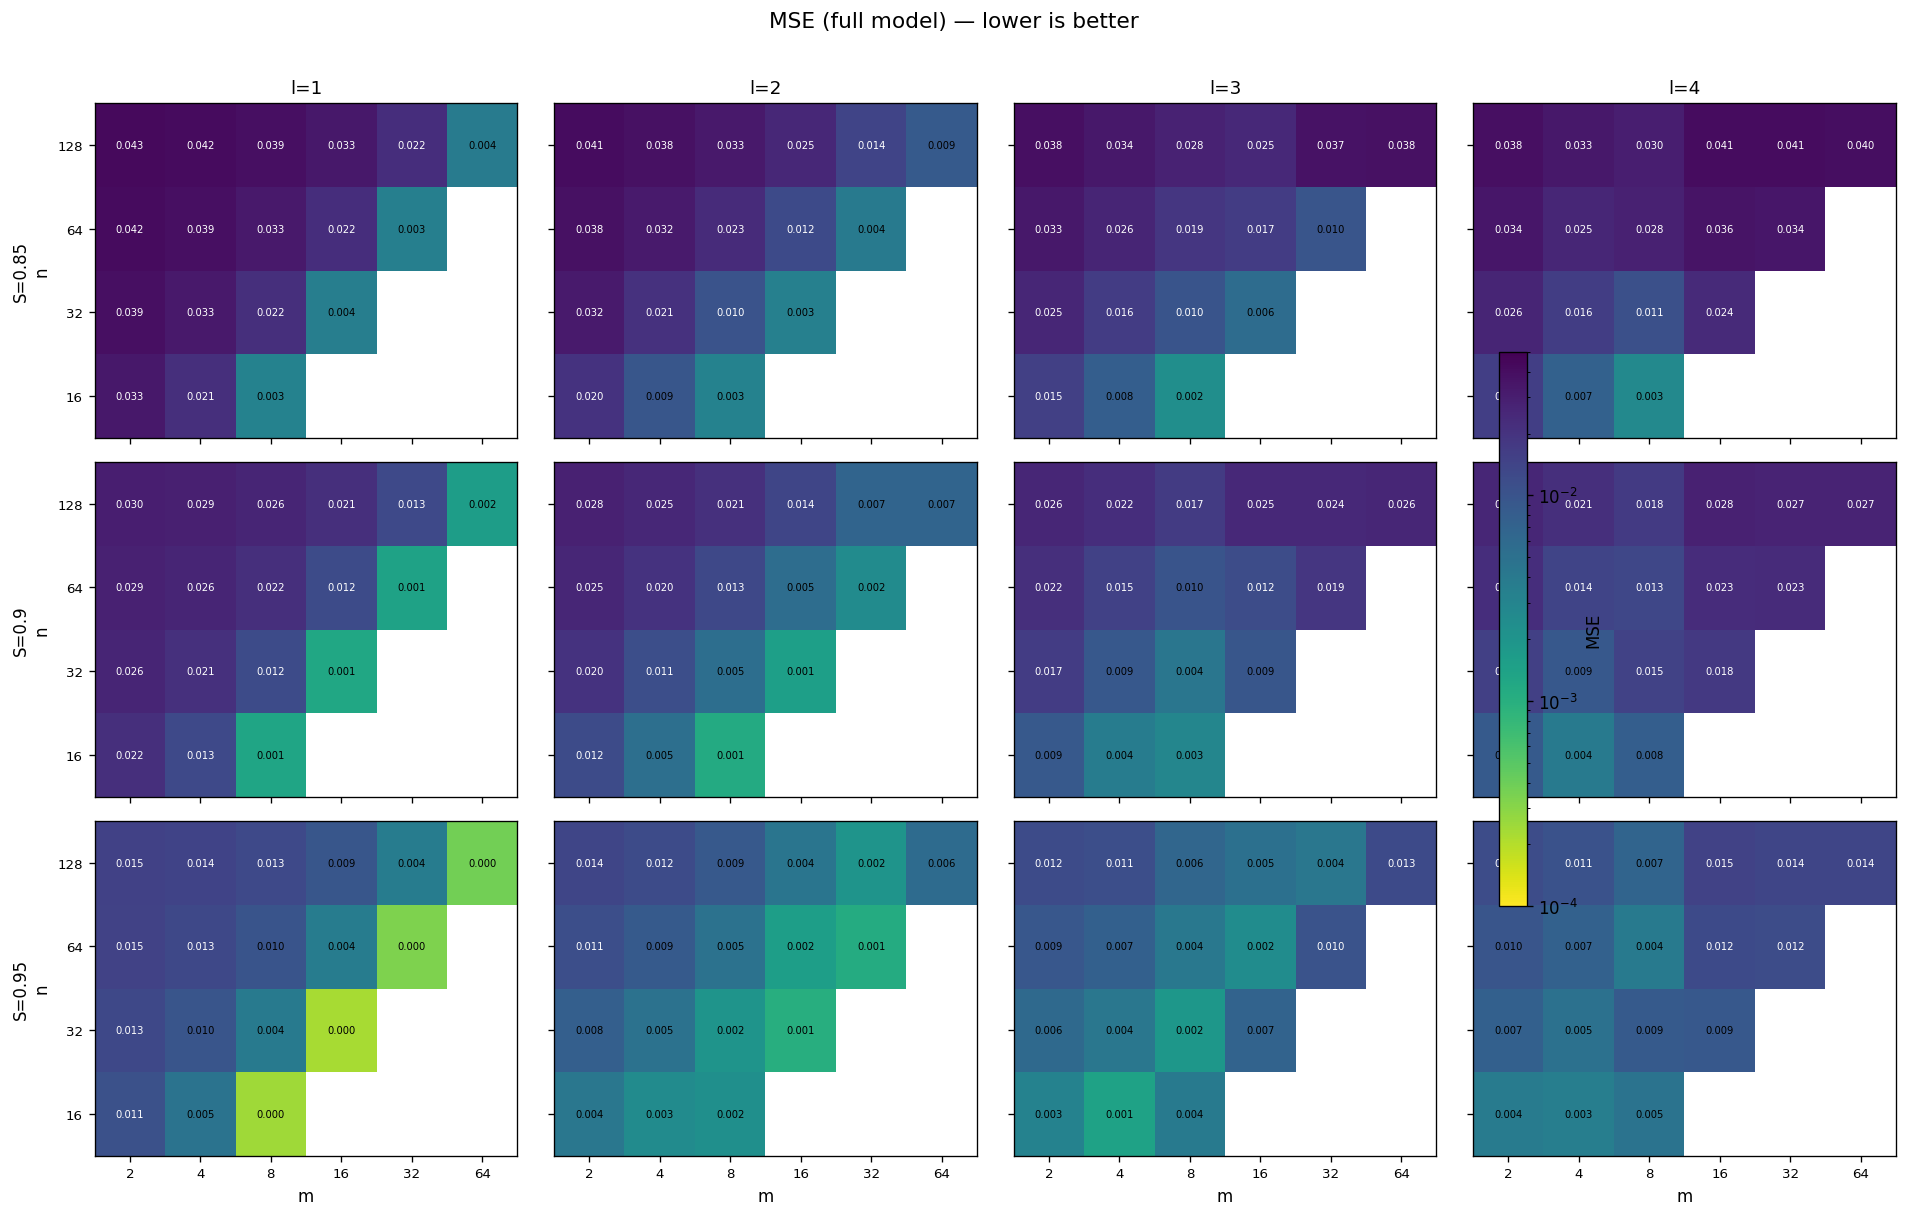

In [12]:
# 2G: MSE heatmaps — same layout as gain, for cross-referencing
fig, axes = plt.subplots(len(S_vals), len(l_vals), figsize=(16, 10),
                          sharex=True, sharey=True)

for i, S in enumerate(S_vals):
    for j, l in enumerate(l_vals):
        ax = axes[i, j]
        sub = df[(df.S == S) & (df.l == l)]
        
        grid = np.full((len(n_vals), len(m_vals)), np.nan)
        for _, row in sub.iterrows():
            ni = n_vals.index(row['n'])
            mi = m_vals.index(row['m'])
            grid[ni, mi] = row['mse_full']
        
        im = ax.imshow(grid, cmap='viridis_r', aspect='auto', origin='lower',
                       norm=mcolors.LogNorm(vmin=1e-4, vmax=0.05))
        
        for ni, n in enumerate(n_vals):
            for mi, m_val in enumerate(m_vals):
                if not np.isnan(grid[ni, mi]):
                    ax.text(mi, ni, f'{grid[ni, mi]:.3f}', ha='center', va='center',
                           fontsize=6, color='white' if grid[ni, mi] > 0.01 else 'black')
        
        ax.set_xticks(range(len(m_vals)))
        ax.set_xticklabels(m_vals, fontsize=8)
        ax.set_yticks(range(len(n_vals)))
        ax.set_yticklabels(n_vals, fontsize=8)
        if i == 0:
            ax.set_title(f'l={l}', fontsize=11)
        if j == 0:
            ax.set_ylabel(f'S={S}\nn', fontsize=10)
        if i == len(S_vals) - 1:
            ax.set_xlabel('m', fontsize=10)

fig.suptitle('MSE (full model) — lower is better', fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, label='MSE', shrink=0.6)
plt.tight_layout()
plt.show()

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_65143/3069306926.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


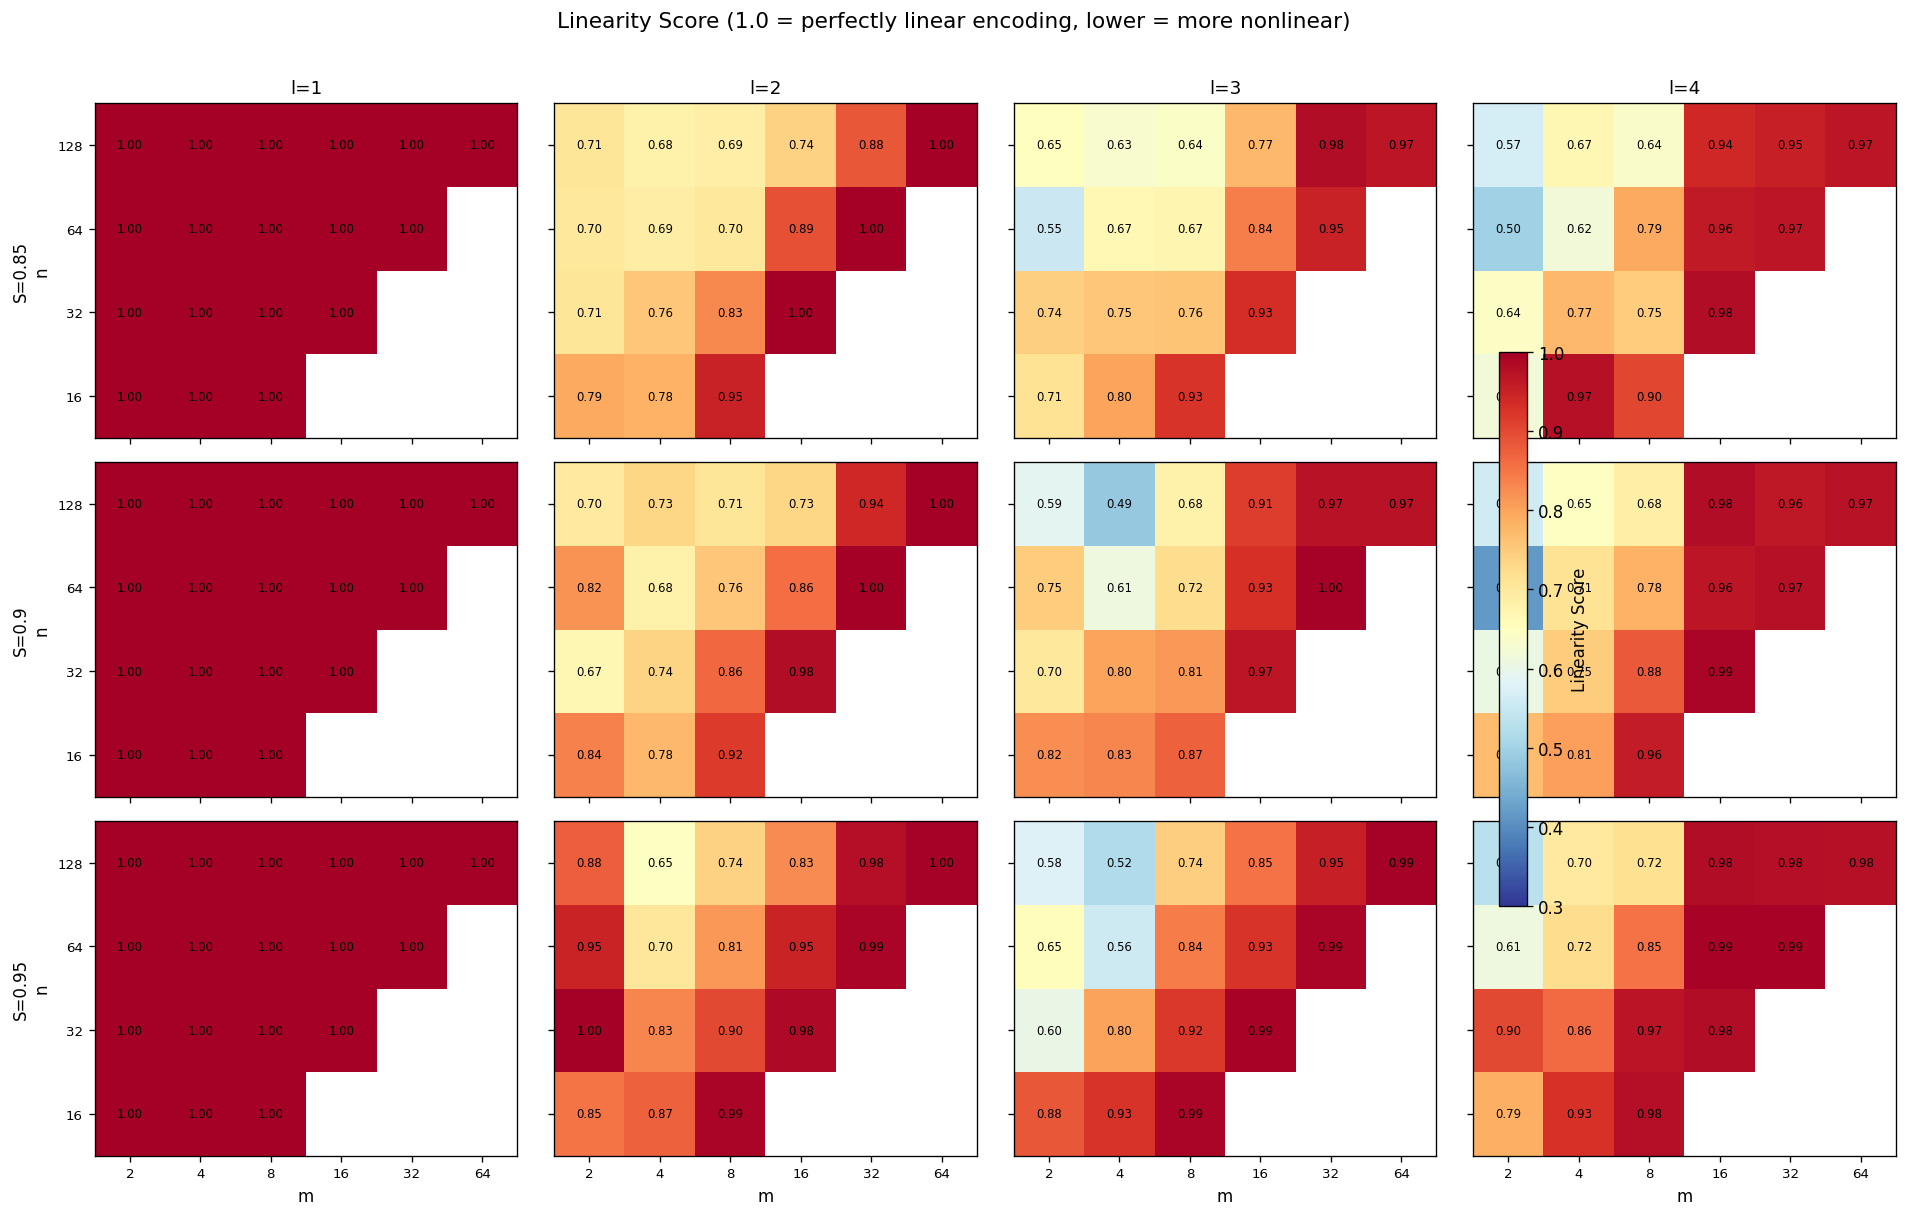

In [13]:
# 2H: Linearity score heatmaps — how nonlinear is the encoding?
fig, axes = plt.subplots(len(S_vals), len(l_vals), figsize=(16, 10),
                          sharex=True, sharey=True)

for i, S in enumerate(S_vals):
    for j, l in enumerate(l_vals):
        ax = axes[i, j]
        sub = df[(df.S == S) & (df.l == l)]
        
        grid = np.full((len(n_vals), len(m_vals)), np.nan)
        for _, row in sub.iterrows():
            ni = n_vals.index(row['n'])
            mi = m_vals.index(row['m'])
            grid[ni, mi] = row['linearity_score']
        
        im = ax.imshow(grid, cmap='RdYlBu_r', vmin=0.3, vmax=1.0,
                       aspect='auto', origin='lower')
        
        for ni, n in enumerate(n_vals):
            for mi, m_val in enumerate(m_vals):
                if not np.isnan(grid[ni, mi]):
                    ax.text(mi, ni, f'{grid[ni, mi]:.2f}', ha='center', va='center',
                           fontsize=7)
        
        ax.set_xticks(range(len(m_vals)))
        ax.set_xticklabels(m_vals, fontsize=8)
        ax.set_yticks(range(len(n_vals)))
        ax.set_yticklabels(n_vals, fontsize=8)
        if i == 0:
            ax.set_title(f'l={l}', fontsize=11)
        if j == 0:
            ax.set_ylabel(f'S={S}\nn', fontsize=10)
        if i == len(S_vals) - 1:
            ax.set_xlabel('m', fontsize=10)

fig.suptitle('Linearity Score (1.0 = perfectly linear encoding, lower = more nonlinear)', fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, label='Linearity Score', shrink=0.6)
plt.tight_layout()
plt.show()

---
## Summary: Suspect Configs and Retrain Recommendations

In [14]:
# Merge all flags into a scoring system
if len(df_suspects) > 0:
    df_suspects['n_flags'] = df_suspects['flags'].str.count(',') + 1
    df_suspects['severity'] = df_suspects['gain_gap'] * df_suspects['n_flags']
    
    print(f"=== SUSPECT CONFIGS: {len(df_suspects)} / {len(df_nl)} nonlinear configs ===")
    print()
    
    # Group by flag type
    all_flags = [f.strip() for flags in df_suspects['flags'] for f in flags.split(',')]
    from collections import Counter
    flag_counts = Counter(all_flags)
    for flag, count in flag_counts.most_common():
        print(f"  {flag}: {count} configs")
    
    print()
    print("Top suspects (sorted by severity):")
    print(df_suspects.sort_values('severity', ascending=False)
          [['n','m','l','S','gain','best_sibling_gain','gain_gap','conv_rate','steps_frac','flags']]
          .head(20).to_string(index=False))
    
    # Recommendations
    print()
    print("=== RETRAIN RECOMMENDATIONS ===")
    ceiling_hits = df_suspects[df_suspects['flags'].str.contains('hit_ceiling')]
    false_conv = df_suspects[df_suspects['flags'].str.contains('low_gain_vs_siblings')]
    underperf = df_suspects[df_suspects['flags'].str.contains('underperforming')]
    
    if len(ceiling_hits) > 0:
        print(f"\n{len(ceiling_hits)} configs hit step ceiling -> increase max_steps 2x")
    if len(false_conv) > 0:
        print(f"{len(false_conv)} configs likely false-converged to linear solution -> 3x seeds + LR sweep")
    if len(underperf) > 0:
        print(f"{len(underperf)} configs underperforming vs siblings -> 2x seeds")
    
    print(f"\nTotal unique configs to retrain: {len(df_suspects)}")
    print(f"Percentage of nonlinear configs: {100*len(df_suspects)/len(df_nl):.0f}%")
else:
    print("No suspect configs found! All results look consistent.")

=== SUSPECT CONFIGS: 53 / 162 nonlinear configs ===

  underperforming_vs_siblings: 27 configs
  high_seed_variance: 26 configs
  low_gain_vs_siblings: 19 configs
  hit_ceiling: 5 configs

Top suspects (sorted by severity):
  n  m  l    S      gain  best_sibling_gain  gain_gap  conv_rate  steps_frac                                             flags
128 16  4 0.90  0.003129           0.935273  0.932144      0.700    0.154689 low_gain_vs_siblings, underperforming_vs_siblings
128 16  4 0.95  0.001630           0.895499  0.893869      1.000    0.154689 low_gain_vs_siblings, underperforming_vs_siblings
 64 16  4 0.85  0.012488           0.784795  0.772307      0.500    0.218762 low_gain_vs_siblings, underperforming_vs_siblings
 64 16  4 0.90  0.012267           0.784542  0.772275      0.700    0.187512 low_gain_vs_siblings, underperforming_vs_siblings
128 16  4 0.85  0.009925           0.775422  0.765497      0.500    0.198883 low_gain_vs_siblings, underperforming_vs_siblings
 64 16  4 0.95